# 实验三：Kaggle 表情图片分类（CNN）

任务：将每张 `48×48` 灰度人脸图片分为 7 类表情。

类别定义：`0 生气`、`1 厌恶`、`2 恐惧`、`3 高兴`、`4 难过`、`5 惊讶`、`6 中立`。

In [1]:
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

SEED = 42
NUM_CLASSES = 7
IMAGE_SIZE = 48
CLASS_NAMES = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

def select_device():
    if not torch.cuda.is_available():
        print("CUDA 不可用，将使用 CPU。")
        return torch.device("cpu")

    capability = torch.cuda.get_device_capability(0)
    gpu_arch = f"sm_{capability[0]}{capability[1]}"
    compiled_arches = set(torch.cuda.get_arch_list())
    gpu_name = torch.cuda.get_device_name(0)
    print("检测到 GPU:", gpu_name, "架构:", gpu_arch)
    print("当前 PyTorch 支持的 CUDA 架构:", sorted(compiled_arches))

    if compiled_arches and gpu_arch not in compiled_arches:
        print(
            f"警告：当前 PyTorch 未包含 {gpu_arch} 的 CUDA 内核，将自动使用 CPU。"
            "请在 Kaggle Settings → Accelerator 中改选 T4，然后 Restart Session 并 Run All。"
        )
        return torch.device("cpu")

    try:
        probe = nn.Conv2d(1, 1, kernel_size=3, padding=1).cuda()
        probe_input = torch.zeros(1, 1, 8, 8, device="cuda")
        _ = probe(probe_input).sum().item()
        del probe, probe_input
        return torch.device("cuda")
    except Exception as error:
        print(
            "警告：CUDA 卷积测试失败，将自动使用 CPU。"
            "建议改选 T4，Restart Session 后重新 Run All。错误类型：",
            type(error).__name__,
        )
        return torch.device("cpu")

DEVICE = select_device()
OUTPUT_DIR = Path(os.environ.get("LAB3_WORKING_DIR", "/kaggle/working"))
if not OUTPUT_DIR.parent.exists():
    OUTPUT_DIR = Path.cwd()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PyTorch:", torch.__version__)
print("设备:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("输出目录:", OUTPUT_DIR)

检测到 GPU: Tesla T4 架构: sm_75
当前 PyTorch 支持的 CUDA 架构: ['sm_100', 'sm_120', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']
PyTorch: 2.10.0+cu128
设备: cuda
GPU: Tesla T4
输出目录: /kaggle/working


## 1. 定位并读取竞赛数据

课件把路径写死为 `/kaggle/input/2024-zjutest-3/`。下面会递归搜索 Kaggle 的 Input 目录，因此能够适应竞赛挂载目录名称变化；最终提交严格使用竞赛要求的 `ID,Label` 表头。

In [2]:
def find_input_files():
    search_roots = []
    env_root = os.environ.get("LAB3_INPUT_ROOT")
    if env_root:
        search_roots.append(Path(env_root).expanduser())
    search_roots.extend([
        Path("/kaggle/input/2024-zjutest-3"),
        Path("/kaggle/input/competitions/2024-zjutest-3"),
        Path("/kaggle/input"),
    ])

    seen = set()
    for root in search_roots:
        if not root.exists():
            continue
        resolved = root.resolve()
        if resolved in seen:
            continue
        seen.add(resolved)

        train_files = sorted(
            p for p in resolved.rglob("*")
            if p.is_file() and p.name.lower() == "train.csv"
        )
        for train_path in train_files:
            test_path = train_path.parent / "test.csv"
            if not test_path.is_file():
                continue
            sample_path = next(
                (train_path.parent / name for name in
                 ("sample.csv", "sample_submission.csv", "Sample.csv")
                 if (train_path.parent / name).is_file()),
                None,
            )
            return train_path.parent, train_path, test_path, sample_path

    kaggle_input = Path("/kaggle/input")
    mounted = []
    if kaggle_input.exists():
        mounted = [
            str(p.relative_to(kaggle_input))
            for p in sorted(kaggle_input.rglob("*"))
            if p.is_file()
        ][:30]
    raise FileNotFoundError(
        "没有在 Kaggle Input 中找到同目录的 train.csv 和 test.csv。"
        "请在 Notebook 右侧选择 Add Input → Competition Data 并添加本次竞赛数据。"
        f"当前已挂载文件（最多显示 30 个）：{mounted}"
    )

INPUT_DIR, TRAIN_PATH, TEST_PATH, SAMPLE_PATH = find_input_files()

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sample_df = pd.read_csv(SAMPLE_PATH) if SAMPLE_PATH is not None else None

print("输入目录:", INPUT_DIR)
print("train:", train_df.shape, list(train_df.columns))
print("test :", test_df.shape, list(test_df.columns))
if sample_df is not None:
    print("sample:", sample_df.shape, list(sample_df.columns))
else:
    print("sample: 未提供，将根据 test.csv 生成 ID,Label")
display(train_df.head(2))
if sample_df is not None:
    display(sample_df.head())

输入目录: /kaggle/input/competitions/2024-zjutest-3
train: (21998, 2) ['label', 'feature']
test : (6711, 2) ['id', 'feature']
sample: (7178, 2) ['id', 'label']


,label,feature
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,151 150 147 155 148 133 111 140 170 174 182 15...


,id,label
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


In [3]:
def pick_column(df, preferred_names, purpose):
    normalized = {str(c).strip().lower(): c for c in df.columns}
    for name in preferred_names:
        if name.lower() in normalized:
            return normalized[name.lower()]
    raise ValueError(f"无法识别{purpose}列；实际列名为 {list(df.columns)}")

def parse_pixels(series, image_size=IMAGE_SIZE):
    expected = image_size * image_size
    rows = []
    for row_index, value in enumerate(series.astype(str)):
        pixels = np.fromstring(value, sep=" ", dtype=np.float32)
        if pixels.size != expected:
            raise ValueError(
                f"第 {row_index} 行含 {pixels.size} 个像素，预期 {expected} 个；请检查像素列和分隔符。"
            )
        rows.append(pixels)
    array = np.stack(rows).reshape(-1, 1, image_size, image_size)
    return array / 255.0

LABEL_COL = pick_column(train_df, ["label", "emotion", "target"], "训练标签")
TRAIN_PIXELS_COL = pick_column(train_df, ["feature", "pixels", "pixel", "image"], "训练像素")
TEST_PIXELS_COL = pick_column(test_df, ["feature", "pixels", "pixel", "image"], "测试像素")

y_all = train_df[LABEL_COL].to_numpy(dtype=np.int64)
X_all = parse_pixels(train_df[TRAIN_PIXELS_COL])
X_test = parse_pixels(test_df[TEST_PIXELS_COL])

observed_labels = sorted(np.unique(y_all).tolist())
if observed_labels != list(range(NUM_CLASSES)):
    raise ValueError(f"训练标签应为 0~6，实际为 {observed_labels}")

print("训练图像:", X_all.shape, X_all.dtype, f"范围 [{X_all.min():.3f}, {X_all.max():.3f}]")
print("训练标签:", y_all.shape, "类别:", observed_labels)
print("测试图像:", X_test.shape)
print("类别计数:", np.bincount(y_all, minlength=NUM_CLASSES))

训练图像: (21998, 1, 48, 48) float32 范围 [0.000, 1.000]
训练标签: (21998,) 类别: [0, 1, 2, 3, 4, 5, 6]
测试图像: (6711, 1, 48, 48)
类别计数: [3062  355 3188 5529 3692 2375 3797]


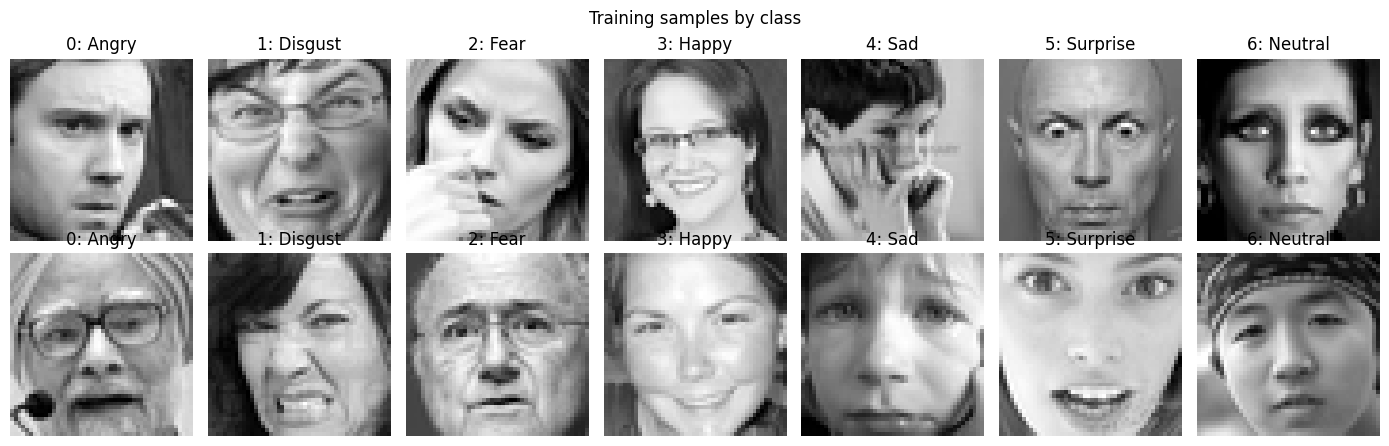

In [4]:
fig, axes = plt.subplots(2, 7, figsize=(14, 4.5))
for label in range(NUM_CLASSES):
    indices = np.flatnonzero(y_all == label)[:2]
    for row, index in enumerate(indices):
        axes[row, label].imshow(X_all[index, 0], cmap="gray")
        axes[row, label].set_title(f"{label}: {CLASS_NAMES[label]}")
        axes[row, label].axis("off")
plt.suptitle("Training samples by class")
plt.tight_layout()
plt.show()

## 2. 分层划分与数据增强

- `stratify=y_all` 让训练集和验证集保留接近的类别比例，比课件中“每 10 行抽一行”更可靠。
- 随机水平翻转与小角度仿射变换模拟轻微姿态差异，只用于训练集。
- 归一化把像素从 `[0,1]` 变换到约 `[-1,1]`，便于优化。

In [5]:
train_idx, val_idx = train_test_split(
    np.arange(len(y_all)),
    test_size=0.15,
    random_state=SEED,
    stratify=y_all,
)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=10, translate=(0.08, 0.08), scale=(0.95, 1.05)),
    transforms.Normalize(mean=(0.5,), std=(0.5,)),
])
eval_transform = transforms.Normalize(mean=(0.5,), std=(0.5,))

class FacialExpressionDataset(Dataset):
    def __init__(self, images, labels=None, transform=None):
        self.images = torch.from_numpy(images).float()
        self.labels = None if labels is None else torch.from_numpy(labels).long()
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image = self.images[index]
        if self.transform is not None:
            image = self.transform(image)
        if self.labels is None:
            return image
        return image, self.labels[index]

train_set = FacialExpressionDataset(X_all[train_idx], y_all[train_idx], train_transform)
val_set = FacialExpressionDataset(X_all[val_idx], y_all[val_idx], eval_transform)
test_set = FacialExpressionDataset(X_test, transform=eval_transform)

BATCH_SIZE = 256 if DEVICE.type == "cuda" else 64
NUM_WORKERS = 2 if DEVICE.type == "cuda" else 0
loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)
train_loader = DataLoader(train_set, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_set, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_set, shuffle=False, **loader_kwargs)

print("训练/验证/测试:", len(train_set), len(val_set), len(test_set))
print("batch size:", BATCH_SIZE)

训练/验证/测试: 18698 3300 6711
batch size: 256


## 3. CNN 结构

课程基线的主干是 `1→64→128→256` 三段卷积，每段后用 `2×2` 最大池化，因此空间尺寸按 `48→24→12→6` 变化。本实现保留这一主干，便于与课件逐层对应。

课件随后使用 `9216→4096→1024→256→7`，仅第一层全连接就有约 3775 万个权重，容易在小数据集上过拟合。本实现改为 `9216→512→128→7`，并配合 BatchNorm、RReLU 和 Dropout，在保留表达能力的同时显著减少参数。

输出层给出 7 个 **logits**（未归一化分数）。`CrossEntropyLoss` 内部已经包含 LogSoftmax，训练时不要再显式加 Softmax；预测只需取 `argmax`。

In [6]:
class ConvBlock(nn.Sequential):
    def __init__(self, in_channels, out_channels):
        super().__init__(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.RReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

class ExpressionCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(1, 64),       # (N, 1, 48, 48) -> (N, 64, 24, 24)
            ConvBlock(64, 128),     # -> (N, 128, 12, 12)
            ConvBlock(128, 256),   # -> (N, 256, 6, 6)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.30),
            nn.Linear(256 * 6 * 6, 512),
            nn.BatchNorm1d(512),
            nn.RReLU(inplace=True),
            nn.Dropout(p=0.50),
            nn.Linear(512, 128),
            nn.RReLU(inplace=True),
            nn.Linear(128, num_classes),
        )
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, nn.Conv2d):
            nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
        elif isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, x):
        return self.classifier(self.features(x))

model = ExpressionCNN().to(DEVICE)
with torch.no_grad():
    shape_check = model(torch.zeros(2, 1, 48, 48, device=DEVICE))
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
assert shape_check.shape == (2, NUM_CLASSES)
print(model)
print(f"可训练参数: {trainable_params:,}")
print("形状检查:", tuple(shape_check.shape))

ExpressionCNN(
  (features): Sequential(
    (0): ConvBlock(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): RReLU(lower=0.125, upper=0.3333333333333333, inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): ConvBlock(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): RReLU(lower=0.125, upper=0.3333333333333333, inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): ConvBlock(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): RReLU(lower=0.125, u

## 4. 损失函数、优化器与训练策略

- **类别加权交叉熵**：样本较少的表情获得更高权重，缓解类别不平衡；`label_smoothing=0.05` 减少过度自信。
- **AdamW**：根据一阶矩和二阶矩自适应调整每个参数的步长，并用独立权重衰减抑制过拟合。
- **学习率调度**：验证准确率连续不提升时将学习率减半。
- **早停与最佳模型**：只保存验证准确率最高的权重，连续 7 轮无提升就停止。
- **混合精度**：GPU 上启用 AMP，以更少显存、更高吞吐进行训练。

In [7]:
class_counts = np.bincount(y_all[train_idx], minlength=NUM_CLASSES)
class_weights = class_counts.sum() / (NUM_CLASSES * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2, min_lr=1e-6
)
scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))

def run_epoch(loader, training):
    model.train(training)
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            if training:
                optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
                logits = model(images)
                loss = criterion(logits, labels)

            if training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                scaler.step(optimizer)
                scaler.update()

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples

EPOCHS = 30
PATIENCE = 7
BEST_PATH = OUTPUT_DIR / "best_expression_cnn.pth"
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = -1.0
stale_epochs = 0

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    train_loss, train_acc = run_epoch(train_loader, training=True)
    val_loss, val_acc = run_epoch(val_loader, training=False)
    scheduler.step(val_acc)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    improved = val_acc > best_val_acc
    if improved:
        best_val_acc = val_acc
        stale_epochs = 0
        torch.save(model.state_dict(), BEST_PATH)
    else:
        stale_epochs += 1

    lr = optimizer.param_groups[0]["lr"]
    print(
        f"[{epoch:02d}/{EPOCHS}] {time.time()-start:6.1f}s "
        f"train loss={train_loss:.4f} acc={train_acc:.4f} | "
        f"val loss={val_loss:.4f} acc={val_acc:.4f} | lr={lr:.2e}"
        + ("  <- saved" if improved else "")
    )

    if stale_epochs >= PATIENCE:
        print(f"验证准确率连续 {PATIENCE} 轮未提升，提前停止。")
        break

assert BEST_PATH.is_file(), "最佳模型文件未生成"
print(f"最佳验证准确率: {best_val_acc:.4f}")
print("最佳权重:", BEST_PATH)

[01/30]    7.7s train loss=2.1937 acc=0.1994 | val loss=1.8974 acc=0.3548 | lr=1.00e-03  <- saved
[02/30]    6.9s train loss=1.9356 acc=0.2647 | val loss=1.8177 acc=0.2379 | lr=1.00e-03
[03/30]    6.7s train loss=1.8554 acc=0.3000 | val loss=1.7148 acc=0.4221 | lr=1.00e-03  <- saved
[04/30]    7.0s train loss=1.7926 acc=0.3340 | val loss=1.7166 acc=0.3879 | lr=1.00e-03
[05/30]    6.9s train loss=1.7367 acc=0.3665 | val loss=1.6534 acc=0.4379 | lr=1.00e-03  <- saved
[06/30]    6.6s train loss=1.7159 acc=0.3835 | val loss=1.6683 acc=0.4015 | lr=1.00e-03
[07/30]    6.6s train loss=1.6841 acc=0.3943 | val loss=1.5886 acc=0.4664 | lr=1.00e-03  <- saved
[08/30]    6.7s train loss=1.6535 acc=0.4120 | val loss=1.5883 acc=0.4867 | lr=1.00e-03  <- saved
[09/30]    6.6s train loss=1.6258 acc=0.4297 | val loss=1.5664 acc=0.4621 | lr=1.00e-03
[10/30]    6.7s train loss=1.6055 acc=0.4437 | val loss=1.5559 acc=0.4915 | lr=1.00e-03  <- saved
[11/30]    6.8s train loss=1.5942 acc=0.4463 | val loss=1.52

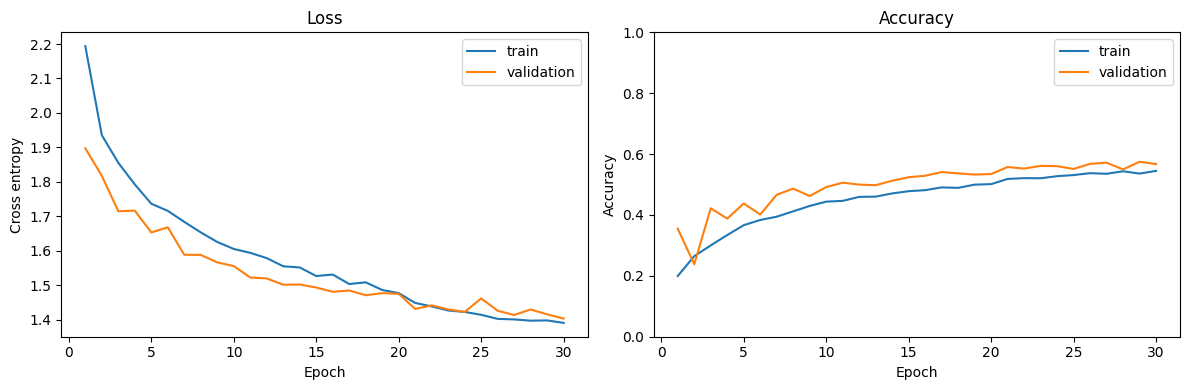

In [8]:
epochs_ran = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_ran, history["train_loss"], label="train")
axes[0].plot(epochs_ran, history["val_loss"], label="validation")
axes[0].set(title="Loss", xlabel="Epoch", ylabel="Cross entropy")
axes[0].legend()

axes[1].plot(epochs_ran, history["train_acc"], label="train")
axes[1].plot(epochs_ran, history["val_acc"], label="validation")
axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1))
axes[1].legend()
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

       Angry     0.5501    0.4423    0.4903       459
     Disgust     0.1780    0.6415    0.2787        53
        Fear     0.4681    0.3536    0.4029       478
       Happy     0.7966    0.7976    0.7971       830
         Sad     0.4874    0.4206    0.4516       554
    Surprise     0.6532    0.7247    0.6871       356
     Neutral     0.5007    0.5930    0.5430       570

    accuracy                         0.5748      3300
   macro avg     0.5192    0.5676    0.5215      3300
weighted avg     0.5863    0.5748    0.5752      3300



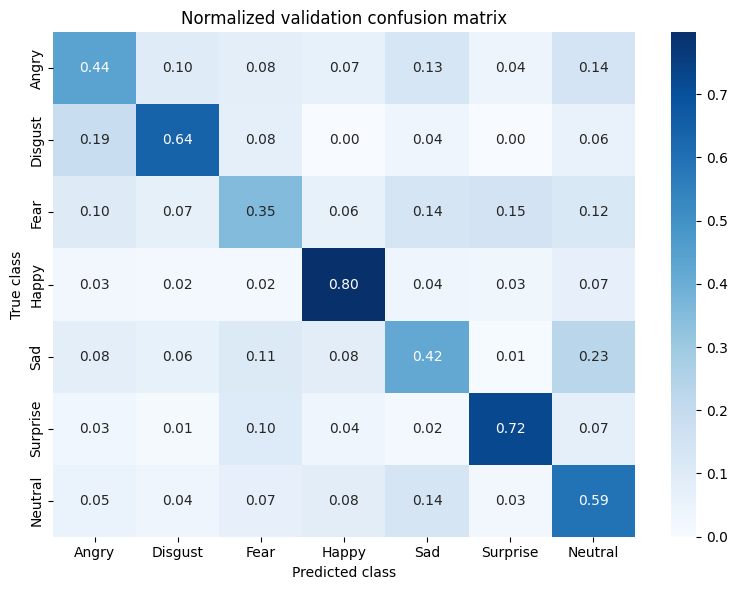

In [9]:
model.load_state_dict(torch.load(BEST_PATH, map_location=DEVICE, weights_only=True))
model.eval()
val_true, val_pred = [], []

with torch.no_grad():
    for images, labels in val_loader:
        logits = model(images.to(DEVICE, non_blocking=True))
        val_pred.extend(logits.argmax(dim=1).cpu().numpy())
        val_true.extend(labels.numpy())

print(classification_report(
    val_true,
    val_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
))

cm = confusion_matrix(val_true, val_pred, labels=list(range(NUM_CLASSES)), normalize="true")
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Normalized validation confusion matrix")
plt.tight_layout()
plt.show()

## 5. 测试集预测与提交

使用简单的测试时增强（TTA）：同一张图片分别按原图和水平翻转图预测，再平均两组 logits。提交文件从 `test.csv` 读取 ID，并严格输出竞赛要求的两个表头：`ID,Label`。

In [10]:
model.eval()
test_predictions = []
with torch.no_grad():
    for images in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        logits_original = model(images)
        logits_flipped = model(torch.flip(images, dims=[3]))
        logits = (logits_original + logits_flipped) / 2
        test_predictions.extend(logits.argmax(dim=1).cpu().numpy())

normalized_test_cols = {str(c).strip().lower(): c for c in test_df.columns}
test_id_col = normalized_test_cols.get("id")
test_ids = test_df[test_id_col].to_numpy() if test_id_col is not None else np.arange(len(test_df))

submission = pd.DataFrame({
    "ID": test_ids,
    "Label": np.asarray(test_predictions, dtype=np.int64),
})

SUBMISSION_PATH = OUTPUT_DIR / "submission.csv"
submission.to_csv(SUBMISSION_PATH, index=False)

reloaded = pd.read_csv(SUBMISSION_PATH)
assert list(reloaded.columns) == ["ID", "Label"]
assert len(reloaded) == len(test_df)
assert reloaded["ID"].equals(pd.Series(test_ids, name="ID"))
assert reloaded["Label"].between(0, NUM_CLASSES - 1).all()

display(reloaded.head(10))
print("提交文件:", SUBMISSION_PATH)
print("行数:", len(reloaded), "标签分布:", reloaded["Label"].value_counts().sort_index().to_dict())

,ID,Label
0,0,5
1,1,2
2,2,4
3,3,0
4,4,3
5,5,4
6,6,4
7,7,6
8,8,1
9,9,2


提交文件: /kaggle/working/submission.csv
行数: 6711 标签分布: {0: 722, 1: 355, 2: 721, 3: 1684, 4: 1024, 5: 837, 6: 1368}


## 6. 算法原理

### 6.1 为什么使用 CNN

普通全连接网络会先把 `48×48` 图片拉平成 2304 维向量，像素之间“上下左右相邻”的空间关系随之变得不明显。CNN 的卷积核只连接局部区域，并在整幅图像上共享同一组参数，因此能依次学习边缘、纹理、眼睛/嘴角形状以及完整表情等层级特征。共享参数也让 CNN 比同规模全连接网络更节省参数。

### 6.2 卷积

对输入特征图 $X$，第 $k$ 个卷积核在位置 $(i,j)$ 的输出为：

$$Y_{k,i,j}=b_k+\sum_c\sum_{u=0}^{2}\sum_{v=0}^{2}W_{k,c,u,v}X_{c,i+u,j+v}$$

这里使用 `3×3` 卷积、步长 1、padding 1，所以卷积前后的高宽不变。通道数从 `1→64→128→256`，表示网络逐层学习更多种特征。输出尺寸通式是：

$$H_{out}=\left\lfloor\frac{H_{in}+2P-K}{S}\right\rfloor+1$$

### 6.3 BatchNorm、RReLU 与最大池化

BatchNorm 在一个 mini-batch 内对每个通道进行标准化，再学习缩放与平移参数，使各层数值尺度更稳定。RReLU 对正数保持不变，对负数保留一个随机小斜率：

$$f(x)=\begin{cases}x,&x\ge 0\\ax,&x<0\end{cases}$$

它既提供非线性，又避免普通 ReLU 的负半轴梯度恒为 0。每个卷积块后的 `2×2` 最大池化在四个相邻值中取最大值，使空间尺寸减半：`48→24→12→6`。这样扩大了后续神经元的感受野，并对小幅位置变化更鲁棒。

### 6.4 Flatten、全连接与 Dropout

第三次池化得到 `256×6×6` 特征图，Flatten 后成为 9216 维特征向量。全连接层把局部特征组合成全局表情证据，最终输出 7 个 logits。Dropout 在训练时随机将部分激活置零，迫使网络不依赖某几个神经元；验证和预测时 `model.eval()` 会自动关闭 Dropout。

### 6.5 Softmax 与交叉熵

若 logits 为 $z_0,\ldots,z_6$，Softmax 概率为：

$$p_k=\frac{e^{z_k}}{\sum_{j=0}^{6}e^{z_j}}$$

真值类别为 $y$ 时，单样本交叉熵是 $L=-\log p_y$。最小化该损失会提高正确类别的相对分数。PyTorch 的 `CrossEntropyLoss` 已在数值稳定的形式下合并 LogSoftmax 与负对数似然，因此模型直接返回 logits，不显式添加 Softmax。

### 6.6 反向传播与 AdamW

前向传播得到损失后，自动微分按链式法则计算每个参数的梯度 $\partial L/\partial\theta$。AdamW 根据梯度的一阶矩和二阶矩为不同参数自适应调整更新幅度，并独立施加权重衰减。一次 epoch 表示训练集中的样本被完整遍历一遍。

### 6.7 泛化与可信验证

训练准确率高而验证准确率低是过拟合。本实现使用分层验证集、数据增强、Dropout、权重衰减、学习率衰减和早停共同缓解它。最终报告应同时给出最佳验证准确率、损失/准确率曲线、混淆矩阵和 Kaggle 分数；验证集用于选模型，测试集只用于生成提交，不能把测试 ID 当成标签参与训练。

### 6.8 从像素到类别的一次完整流程

`CSV 像素字符串 → 48×48 灰度张量 → 归一化/训练增强 → 三段卷积提取特征 → 6×6×256 → Flatten → 全连接组合特征 → 7 个 logits → argmax 得到 0~6 → 按 sample.csv 的 ID 与列名写入 submission.csv`。